# Baseline Model Experiments

Goals:
- Train Logistic Regression baseline
- Train XGBoost final model
- Compare metrics
- Visualise calibration

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
from src.ingestion.load_data import load_raw
from src.processing.preprocess import clean_raw, build_scaler, apply_scaler
from src.features.feature_store import add_derived_features
from src.processing.split import split_dataset, get_X_y

df_raw = load_raw()
df = add_derived_features(clean_raw(df_raw))
df_train, df_val, df_test = split_dataset(df)

X_train_raw, y_train = get_X_y(df_train)
X_val_raw, y_val   = get_X_y(df_val)
X_test_raw, y_test  = get_X_y(df_test)

scaler = build_scaler(X_train_raw)
X_train = apply_scaler(X_train_raw, scaler)
X_val   = apply_scaler(X_val_raw,   scaler)
X_test  = apply_scaler(X_test_raw,  scaler)

feature_names = list(X_train.columns)
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

2026-03-16 21:55:45 [INFO] src.ingestion.load_data: Loaded raw data: 30000 rows x 24 cols
2026-03-16 21:55:45 [DEBUG] src.processing.preprocess: Raw data cleaned: 30000 rows
2026-03-16 21:55:45 [DEBUG] src.features.feature_store: Derived features added. Total columns: 32
2026-03-16 21:55:45 [INFO] src.processing.split: Split -> train: 21000 | val: 4500 | test: 4500
2026-03-16 21:55:45 [INFO] src.processing.split:   train default rate: 22.12%
2026-03-16 21:55:45 [INFO] src.processing.split:   val default rate: 22.11%
2026-03-16 21:55:45 [INFO] src.processing.split:   test default rate: 22.11%
Train: (21000, 31) | Val: (4500, 31) | Test: (4500, 31)


## Baseline: Logistic Regression

In [3]:
from src.models.train import train_baseline
from src.models.evaluate import compute_metrics

lr = train_baseline(X_train, y_train)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_metrics = compute_metrics(y_test, lr_proba, name='Logistic Regression')
print(lr_metrics)

2026-03-16 21:55:47 [INFO] src.models.train: Baseline (LR) trained. Coeff range: [-0.2435, 0.5249]
2026-03-16 21:55:47 [INFO] src.models.evaluate: [Logistic Regression] ROC-AUC=0.7484 | PR-AUC=0.5097 | Brier=0.1913 | F1=0.5090
{'name': 'Logistic Regression', 'threshold': 0.5, 'roc_auc': 0.7484277306647359, 'pr_auc': 0.5097491479074935, 'brier_score': 0.19133070582840533, 'precision': 0.4441947565543071, 'recall': 0.5959798994974874, 'f1': 0.5090128755364807, 'support_positive': 995, 'support_total': 4500, 'default_rate': 0.22111111111111112, 'predicted_default_rate': 0.2966666666666667, 'confusion_matrix': [[2763, 742], [402, 593]], 'tn': 2763, 'fp': 742, 'fn': 402, 'tp': 593}


c:\Users\dipes\anaconda3\envs\risk-scoring-system\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## XGBoost

In [4]:
from src.models.train import train_xgboost

xgb = train_xgboost(X_train, y_train, X_val, y_val)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_metrics = compute_metrics(y_test, xgb_proba, name='XGBoost (raw)')
print(xgb_metrics)

2026-03-16 21:55:50 [INFO] src.models.train: XGBoost trained. Best iteration: N/A
2026-03-16 21:55:50 [INFO] src.models.evaluate: [XGBoost (raw)] ROC-AUC=0.7819 | PR-AUC=0.5633 | Brier=0.1705 | F1=0.5380
{'name': 'XGBoost (raw)', 'threshold': 0.5, 'roc_auc': 0.7819211607251665, 'pr_auc': 0.5633357600448119, 'brier_score': 0.170530304312706, 'precision': 0.4756756756756757, 'recall': 0.6190954773869347, 'f1': 0.5379912663755458, 'support_positive': 995, 'support_total': 4500, 'default_rate': 0.22111111111111112, 'predicted_default_rate': 0.2877777777777778, 'confusion_matrix': [[2826, 679], [379, 616]], 'tn': 2826, 'fp': 679, 'fn': 379, 'tp': 616}


## Calibration

In [5]:
from src.models.calibrate import calibrate_model

xgb_cal = calibrate_model(xgb, X_val, y_val)
cal_proba = xgb_cal.predict_proba(X_test)[:, 1]
cal_metrics = compute_metrics(y_test, cal_proba, name='XGBoost (calibrated)')
print(cal_metrics)

2026-03-16 21:55:50 [INFO] src.models.calibrate: Model calibrated using isotonic method (sklearn 1.8.0 path).
2026-03-16 21:55:50 [INFO] src.models.evaluate: [XGBoost (calibrated)] ROC-AUC=0.7804 | PR-AUC=0.5375 | Brier=0.1347 | F1=0.4711
{'name': 'XGBoost (calibrated)', 'threshold': 0.5, 'roc_auc': 0.7804424404476018, 'pr_auc': 0.5374553685751715, 'brier_score': 0.13469450175762177, 'precision': 0.6819047619047619, 'recall': 0.3597989949748744, 'f1': 0.4710526315789474, 'support_positive': 995, 'support_total': 4500, 'default_rate': 0.22111111111111112, 'predicted_default_rate': 0.11666666666666667, 'confusion_matrix': [[3338, 167], [637, 358]], 'tn': 3338, 'fp': 167, 'fn': 637, 'tp': 358}


## Comparison

In [6]:
from src.models.evaluate import compare_models, plot_roc_curve, plot_calibration_curve
from pathlib import Path

print(compare_models([lr_metrics, xgb_metrics, cal_metrics]))

plot_roc_curve(y_test,
    {'LR': lr_proba, 'XGB': xgb_proba, 'XGB cal': cal_proba},
    save_path=Path('../reports/figures/roc_curves.png'))

plot_calibration_curve(y_test,
    {'XGB raw': xgb_proba, 'XGB calibrated': cal_proba},
    save_path=Path('../reports/figures/calibration_curves.png'))

                      ROC-AUC  PR-AUC   Brier      F1  Recall  Precision
Model                                                                   
Logistic Regression    0.7484  0.5097  0.1913  0.5090  0.5960     0.4442
XGBoost (raw)          0.7819  0.5633  0.1705  0.5380  0.6191     0.4757
XGBoost (calibrated)   0.7804  0.5375  0.1347  0.4711  0.3598     0.6819
2026-03-16 21:55:50 [INFO] src.models.evaluate: ROC curve saved -> ..\reports\figures\roc_curves.png
2026-03-16 21:55:50 [INFO] src.models.evaluate: Calibration curve saved -> ..\reports\figures\calibration_curves.png


## Score distribution

band
Low       3474
Medium     523
High       503
Name: count, dtype: int64


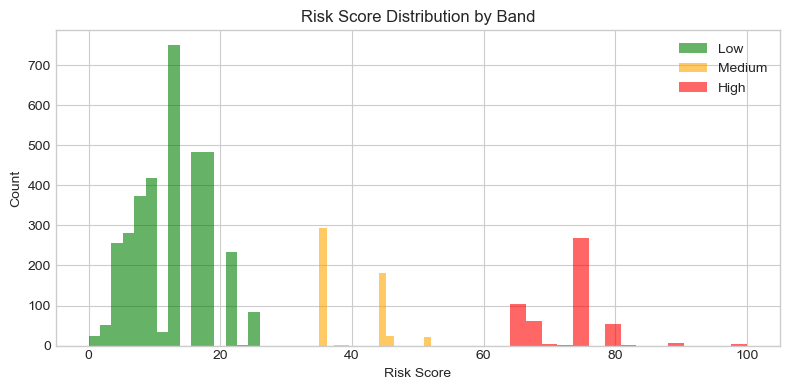

In [7]:
from src.models.calibrate import probability_to_score, score_to_band

scores = probability_to_score(cal_proba)
bands  = [score_to_band(s) for s in scores]

import pandas as pd
result_df = pd.DataFrame({'score': scores, 'band': bands, 'true_label': y_test})
print(result_df['band'].value_counts())

fig, ax = plt.subplots(figsize=(8, 4))
for band, color in [('Low', 'green'), ('Medium', 'orange'), ('High', 'red')]:
    subset = result_df[result_df['band'] == band]['score']
    ax.hist(subset, bins=15, alpha=0.6, label=band, color=color)
ax.set_xlabel('Risk Score')
ax.set_ylabel('Count')
ax.set_title('Risk Score Distribution by Band')
ax.legend()
plt.tight_layout()
plt.show()